In [1]:
# Importing Pyspark packages
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt

In [2]:
# Starting Spark session
spark = (
    SparkSession.builder
    .appName("NYC Taxi Analytics Assignment")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 03:52:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Reading in the data
yellow_path = "../data/yellow_tripdata_2026-01.parquet"
green_path = "../data/green_tripdata_2026-01.parquet"

yellow_raw = spark.read.parquet(yellow_path)
green_raw = spark.read.parquet(green_path)

In [4]:
# Yellow taxi schema
yellow_raw.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [5]:
# Green taxi schema
green_raw.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- lpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- trip_type: long (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [6]:
# Quick view of the dataset
yellow_raw.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-01-01 00:54:04 |2026-01-01 00:59:37  |1              |0.97         |1         |N                 |239         |238 

In [7]:
# Standardizing column names between yellow and green taxi datasets
# Here, we also add a column to label each taxi record (each row) as a green or yellow taxi
# Start with yellow taxis
def standardize_yellow_taxis(df):
    return(df.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime")
           .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")
           .withColumn("taxi_type", lit("yellow")))

def standardize_green_taxis(df):
    return(df.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime")
           .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")
           .withColumn("taxi_type", lit("green")))

yellow_std = standardize_yellow_taxis(yellow_raw)
green_std = standardize_green_taxis(green_raw)


In [8]:
# Cleaning the data (the approach here is to write one common function to clean both datasets)
def cleaning_function(df):
    return(df.filter(col("pickup_datetime").isNotNull())
           .filter(col("dropoff_datetime").isNotNull()) # these steps remove rows with missing timestamps for picks and drops
           .filter(col("trip_distance") > 0) # removes trip with negative or zero distance
           .filter(col("fare_amount") >= 0) # removes non-positive trip fares
           .filter(col("total_amount") >= 0) # removes trips with negative total amount
           .filter(col("dropoff_datetime") >= col("pickup_datetime")) # ensures pickup before dropoff
           .filter((unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))) <= 24*60*60)) # remove trips longer than 24 hours
           
yellow_cleaned = cleaning_function(yellow_std)
green_cleaned = cleaning_function(green_std)

In [9]:
# Checking the number of rows before and after cleaning for each dataset
print("Yellow rows pre-clean:", yellow_std.count())
print("Yellow rows post-clean:", yellow_cleaned.count())
print("Green rows pre-clean:", green_std.count())
print("Green rows post-clean:", green_cleaned.count())

Yellow rows pre-clean: 3724889


Yellow rows post-clean: 3562033
Green rows pre-clean: 40272
Green rows post-clean: 38913


In [10]:
# Question 2: What was the average fare by taxi type?
taxi_fares = (yellow_cleaned.select("taxi_type", "fare_amount").unionByName(green_cleaned.select("taxi_type", "fare_amount")))
average_fare_by_taxi_type = (taxi_fares.groupBy("taxi_type").agg(round(avg("fare_amount"), 2).alias("avg_fare")).orderBy("taxi_type"))
average_fare_by_taxi_type.show()


[Stage 15:======================================>                   (2 + 1) / 3]

+---------+--------+
|taxi_type|avg_fare|
+---------+--------+
|    green|    16.0|
|   yellow|   21.02|
+---------+--------+



In [11]:
# Question 3: What was the average trip distance by taxi type?
taxi_distances = (yellow_cleaned.select("taxi_type", "trip_distance").unionByName(green_cleaned.select("taxi_type", "trip_distance")))
average_distance_by_taxi_types = (taxi_distances.groupBy("taxi_type").agg(round(avg("trip_distance"), 2).alias("avg_trip_distance")).orderBy("taxi_type"))
average_distance_by_taxi_types.show()

[Stage 18:===================>                                      (1 + 2) / 3]

+---------+-----------------+
|taxi_type|avg_trip_distance|
+---------+-----------------+
|    green|            12.99|
|   yellow|             6.71|
+---------+-----------------+



In [12]:
# Question 4: What hour of day had the most pickups?
taxi_picks = (yellow_cleaned.select("pickup_datetime").unionByName(green_cleaned.select("pickup_datetime")))
pickups_by_hour = taxi_picks.withColumn("pickup_hour", hour("pickup_datetime")).groupBy("pickup_hour").count().orderBy(desc("count"))
pickups_by_hour.show(1)

[Stage 21:======================================>                   (2 + 1) / 3]

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         18|235765|
+-----------+------+
only showing top 1 row


In [13]:
# Question 5: What percentage of trips were under 2 miles?
taxi_distance = (yellow_cleaned.select("trip_distance").unionByName(green_cleaned.select("trip_distance")))
total_trips = taxi_distance.count()
under_2 = (taxi_distance.filter(col("trip_distance")<2).count())
percent_under_2 = (under_2/total_trips)*100
print(f"{percent_under_2:.2f}% is the percentage of trips under 2 miles.")

[Stage 27:===================>                                      (1 + 2) / 3]

52.12% is the percentage of trips under 2 miles.


In [14]:
# Question 8: Predict the fare amount using non-fare predictor columns.
# We start by selecting the columns that we will use for modeling and building a combined dataset.
model_df = (yellow_cleaned.select("taxi_type","pickup_datetime","passenger_count", "trip_distance", "PULocationID", "DOLocationID", "fare_amount")
            .unionByName(
            green_cleaned.select("taxi_type","pickup_datetime","passenger_count", "trip_distance", "PULocationID", "DOLocationID", "fare_amount")))
# Creating predictor columns that have time elements
model_df = (model_df.withColumn("pickup_hour", hour("pickup_datetime"))
            .withColumn("pickup_dayofweek", dayofweek("pickup_datetime"))
            .drop("pickup_datetime")
            .na.drop())
# Train-test split
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed = 42)
print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())
# Building RF model
taxi_type_indexer = StringIndexer(inputCol = "taxi_type", outputCol = "taxi_type_index", handleInvalid = "keep")
feature_cols = ["taxi_type_index", "passenger_count","trip_distance","PULocationID","DOLocationID","pickup_hour","pickup_dayofweek"]
assembler = VectorAssembler(inputCols = feature_cols, outputCol = "features", handleInvalid = "skip")
rf = RandomForestRegressor(featuresCol = "features", labelCol = "fare_amount", predictionCol = "predicted_fare", numTrees = 50, maxDepth = 8, seed = 42)
pipeline = Pipeline(stages = [taxi_type_indexer, assembler, rf])



Training rows: 2080219


[Stage 33:======================================>                   (2 + 1) / 3]

Testing rows: 520062


In [15]:
# Model fitting
rf_model = pipeline.fit(train_df)
train_predictions = rf_model.transform(train_df)
test_predictions = rf_model.transform(test_df)

# Evaluating the RMSE
evaluator = RegressionEvaluator(labelCol = "fare_amount", predictionCol = "predicted_fare", metricName = "rmse")
train_rmse = evaluator.evaluate(train_predictions)
test_rmse = evaluator.evaluate(test_predictions)

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")


26/05/23 03:53:52 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:53:52 WARN BlockManager: Persisting block rdd_160_0 to disk instead.
26/05/23 03:54:03 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:54:13 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:54:25 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:54:38 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:54:55 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:55:15 WARN MemoryStore: Not enough space to cache rdd_160_0 in memory! (computed 212.1 MiB so far)
26/05/23 03:55:35 WARN DAGScheduler: Broadcasting large task binary with size 1078.2 KiB
26/05/23 03:55:37 WARN MemoryStore: Not enough space 

Training RMSE: 7.43
Testing RMSE: 7.56


In [16]:
# Importance of predictors
rf_stage = rf_model.stages[-1]
feature_importances = list(zip(feature_cols, rf_stage.featureImportances.toArray()))
for feature, importance in sorted(feature_importances, key = lambda x: x[1], reverse = True):
    print(f"{feature}: {importance:.4f}")

trip_distance: 0.8371
PULocationID: 0.1110
DOLocationID: 0.0430
passenger_count: 0.0043
pickup_hour: 0.0033
pickup_dayofweek: 0.0009
taxi_type_index: 0.0005


In [20]:
# Analysis of Predictor Importance
# The RF model highlighted that trip distance was the most important predictor of the fare amount at a score of 0.8371
# This largely makes sense given that taxi fares are usually determined by travelled distance
# making the trip distance the biggest primary driver of pricing. The second most important factor
# was pickup location with an importance of 0.1110, significantly lower than the trip distance. This means that 
# fares vary significantly across pickup zones due to demand differences and demand for travel. 
# Other predictors like the passenger count, pickup hour, and taxi type, had very small importance scores,
# indicating that they provided relatively little additional information for predicting fare amount. Overall, the results
# highlight that fare prediction is primarily driven fare amount, while location based variables also provide secondary predictive power. 


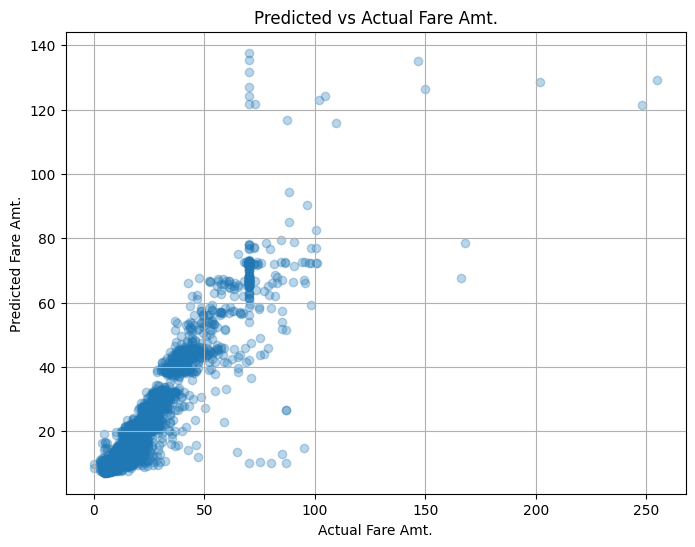

In [18]:
plot_df = (test_predictions.select("fare_amount", "predicted_fare").sample(False, 0.01, seed = 42)
           .limit(5000).toPandas())
plt.figure(figsize = (8, 6))
plt.scatter(plot_df["fare_amount"], plot_df["predicted_fare"], alpha = 0.3)
plt.xlabel("Actual Fare Amt.")
plt.ylabel("Predicted Fare Amt.")
plt.title("Predicted vs Actual Fare Amt.")
plt.grid(True)

plt.savefig("predicted_vs_actual_fare.png" , dpi = 300, bbox_inches = "tight")
plt.show()

In [19]:
# Write the above graph to S3
!aws s3 cp predicted_vs_actual_fare.png s3://yash-hw3/hw3_outputs/predicted_vs_actual_fare.png

upload: ./predicted_vs_actual_fare.png to s3://yash-hw3/hw3_outputs/predicted_vs_actual_fare.png


In [23]:
# Writing files to S3 (Part 7)
output_base_local = "nyc-taxi-assignment"

average_fare_by_taxi_type.write.mode("overwrite").parquet(
    f"{output_base_local}/average_fare_by_taxi_type"
)

pickups_by_hour.write.mode("overwrite").parquet(
    f"{output_base_local}/pickups_by_hour"
)

average_distance_by_taxi_types.write.mode("overwrite").parquet(
    f"{output_base_local}/average_distance_by_taxi_types"
)

In [24]:
!aws s3 cp nyc-taxi-assignment s3://yash-hw3/nyc-taxi-assignment --recursive

upload: nyc-taxi-assignment/average_fare_by_taxi_type/._SUCCESS.crc to s3://yash-hw3/nyc-taxi-assignment/average_fare_by_taxi_type/._SUCCESS.crc
upload: nyc-taxi-assignment/pickups_by_hour/_SUCCESS to s3://yash-hw3/nyc-taxi-assignment/pickups_by_hour/_SUCCESS
upload: nyc-taxi-assignment/average_distance_by_taxi_types/part-00000-f2764f4c-de36-47d1-abe8-8d1f4a33499c-c000.snappy.parquet to s3://yash-hw3/nyc-taxi-assignment/average_distance_by_taxi_types/part-00000-f2764f4c-de36-47d1-abe8-8d1f4a33499c-c000.snappy.parquet
upload: nyc-taxi-assignment/average_fare_by_taxi_type/.part-00000-571203b5-fa04-44fd-8bb4-66232bbc72b6-c000.snappy.parquet.crc to s3://yash-hw3/nyc-taxi-assignment/average_fare_by_taxi_type/.part-00000-571203b5-fa04-44fd-8bb4-66232bbc72b6-c000.snappy.parquet.crc
upload: nyc-taxi-assignment/average_distance_by_taxi_types/.part-00000-f2764f4c-de36-47d1-abe8-8d1f4a33499c-c000.snappy.parquet.crc to s3://yash-hw3/nyc-taxi-assignment/average_distance_by_taxi_types/.part-00000-f2